# Neural Networks Project: Drowsiness Detection

## Importing necessary libraries

In [2]:
### **Importing necessary libraries**

In [3]:
import numpy as np
import pandas as pd 
import os
import cv2
import matplotlib.pyplot as plt

# Use a transfer-learning friendly resolution for MobileNetV2.
IMG_SIZE = 160

## Getting labels for the train dataset

In [4]:
labels = os.listdir("train")
labels

['Closed', 'd_1.mp4', 'no_yawn', 'n_1.mp4', 'Open', 'yawn']

### Example Image: Eyes closed because it is a sign of drowsiness

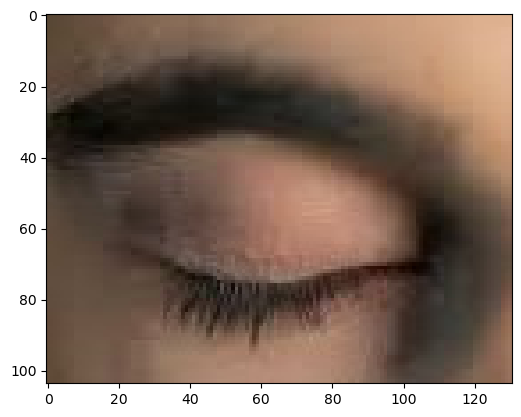

In [5]:
plt.imshow(plt.imread("train/Closed/_26.jpg"))

###  Plotting an image with mouth open because yawning is also a sign of drowsiness

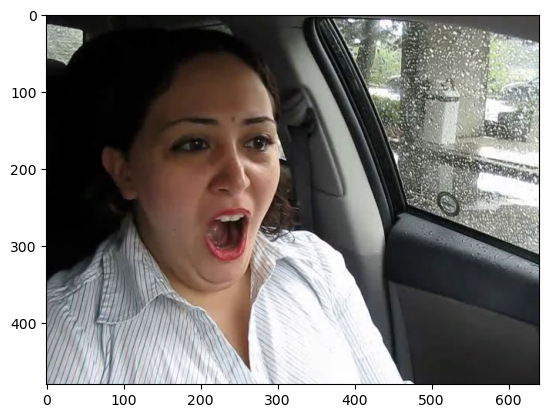

In [6]:
plt.imshow(plt.imread("train/yawn/109.jpg"))  # display the first image in the yawn_no_yawn list

## Preprocessing Images
### Yawning Dataset: Resizing + Crop Faces + Yawning Label

In [7]:
def mouth_box_from_face_xywh(x, y, w, h):
    # Heuristic mouth region from a detected face box.
    mx = x + int(0.18 * w)
    my = y + int(0.58 * h)
    mw = int(0.64 * w)
    mh = int(0.34 * h)
    return (mx, my, mw, mh)

def face_for_yawn(
    direc="train",
    face_cas_path=cv2.data.haarcascades + "haarcascade_frontalface_default.xml",
    use_mouth_crop=True,
    drop_no_face=True,
):
    yaw_no = []  # [image, class_id]
    categories = ["yawn", "no_yawn"]
    face_cascade = cv2.CascadeClassifier(face_cas_path)

    stats = {
        "total_images": 0,
        "used_samples": 0,
        "no_face": 0,
        "bad_mouth_crop": 0,
        "yawn_used": 0,
        "no_yawn_used": 0,
    }

    for category in categories:
        path_link = os.path.join(direc, category)
        class_num1 = categories.index(category)
        print(class_num1)
        for image in os.listdir(path_link):
            stats["total_images"] += 1
            image_array = cv2.imread(os.path.join(path_link, image), cv2.IMREAD_COLOR)
            if image_array is None:
                continue

            gray = cv2.cvtColor(image_array, cv2.COLOR_BGR2GRAY)
            faces = face_cascade.detectMultiScale(
                gray,
                scaleFactor=1.2,
                minNeighbors=6,
                minSize=(60, 60),
            )

            if len(faces) == 0:
                stats["no_face"] += 1
                if drop_no_face:
                    continue
                resized_array = cv2.resize(image_array, (IMG_SIZE, IMG_SIZE))
                yaw_no.append([resized_array, class_num1])
                stats["used_samples"] += 1
                stats[f"{category}_used"] += 1
                continue

            # Keep one face per image (largest) to reduce duplicate near-identical samples.
            x, y, w, h = max(faces, key=lambda f: f[2] * f[3])

            if use_mouth_crop:
                mx, my, mw, mh = mouth_box_from_face_xywh(x, y, w, h)
                roi_color = image_array[my:my+mh, mx:mx+mw]
                if roi_color is None or roi_color.size == 0:
                    stats["bad_mouth_crop"] += 1
                    continue
            else:
                roi_color = image_array[y:y+h, x:x+w]

            resized_array = cv2.resize(roi_color, (IMG_SIZE, IMG_SIZE))
            yaw_no.append([resized_array, class_num1])
            stats["used_samples"] += 1
            stats[f"{category}_used"] += 1

    return yaw_no, stats

yawn_no_yawn, yawn_stats = face_for_yawn(use_mouth_crop=True, drop_no_face=True)
count = yawn_stats["no_face"]
fallback_rate = 100.0 * count / max(1, yawn_stats["total_images"])
print(
    "No-face images:", count,
    "Total images:", yawn_stats["total_images"],
    f"Fallback rate: {fallback_rate:.2f}%",
)
print(
    "Used yawn/no_yawn samples:", yawn_stats["used_samples"],
    "(yawn:", yawn_stats["yawn_used"], ", no_yawn:", yawn_stats["no_yawn_used"], ")",
)

0
1
No-face images: 915 Total images: 1448 Fallback rate: 63.19%
Used yawn/no_yawn samples: 533 (yawn: 280 , no_yawn: 253 )


### Eyes Dataset: Resizing Images + Eyes Label

In [8]:
# This function is getting data from a directory
# It is resizing the images to a specified size and appending the resized image and its label to a list
# The function returns the list of data
def get_data(dir_path="train/"):
    # Define the labels for the data
    labels = ['Closed', 'Open']
    # Create an empty list to store the data
    data = []
    # Loop through each label in the labels list
    for label in labels:
        # Define the path to the label's directory
        path = os.path.join(dir_path, label)
        # Get the index of the label in the labels list
        class_num = labels.index(label)
        # Add 2 to the class number to account for the additional classes for face and eyes
        class_num += 2
        # Loop through each image in the label's directory
        for img in os.listdir(path):
            try:
                # Read in the image and resize it
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_COLOR)
                if img_array is None:
                    continue
                resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                # Append the resized image and its label to the data list
                data.append([resized_array, class_num])
            except Exception as e:
                print(e)
    # Return the list of data
    return data
data_train = get_data()

### Checking the shape of data

In [9]:
data_train[0][0].shape

(160, 160, 3)

### Preprocessed Data Combination

In [10]:
def append_data():
    # Build yawn/no_yawn with mouth-focused preprocessing.
    yaw_no, yawn_stats = face_for_yawn(use_mouth_crop=True, drop_no_face=True)
    
    # Build Closed/Open eye samples.
    data = get_data()
    
    # Merge both datasets for 4-class training.
    yaw_no.extend(data)
    
    # convert the resulting list to a NumPy array and return it
    return (yaw_no, yawn_stats)

new_data, yawn_stats = append_data()
print(
    "Combined dataset size:", len(new_data),
    "| yawn/no_yawn used:", yawn_stats["used_samples"],
    "| no-face dropped:", yawn_stats["no_face"],
)

0
1
Combined dataset size: 1985 | yawn/no_yawn used: 533 | no-face dropped: 915


### Transforming Appended Dataset and Splitting Features

In [11]:
# Initialize empty lists to store features and labels
X = []
y = []

# Iterate over each tuple of feature and label in the new_data list
for feature, label in new_data:
    
    # Append the feature to the X list
    X.append(feature)
    
    # Append the label to the y list
    y.append(label)
# Features
X = np.array(X, dtype=np.float32)
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 3)

### One-hot Encoding the Labels (possible classes 0,1,2,3) using Label Binarizer

In [12]:
from sklearn.preprocessing import LabelBinarizer
label_bin = LabelBinarizer()
y = label_bin.fit_transform(y)

In [13]:
# psaLabels
y = np.array(y)

### Data Splitting

In [14]:
from sklearn.model_selection import train_test_split
seed = 42
test_size = 0.20
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=seed, test_size=test_size)

### Modelling: Importing Modules

In [15]:
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix
import tensorflow as tf

### Data Augmentation and MobileNetV2 Preprocessing

In [16]:
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_generator = test_datagen.flow(
    X_test, y_test,
    batch_size=BATCH_SIZE,
    shuffle=False
)

## MobileNetV2 Transfer Learning (Frozen + Fine-Tuning)
### Base Model Compilation:

In [17]:
# Build MobileNetV2 base model
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

# Build classification head
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(4, activation="softmax")(x)

model = Model(inputs, outputs)

# Stage 1 compile: train only custom head
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 160, 160, 3)]     0         
                                                                 
 mobilenetv2_1.00_160 (Funct  (None, 5, 5, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 batch_normalization (BatchN  (None, 1280)             5120      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                             

### Training base Model using callbacks

In [18]:
stage1_checkpoint = "best_mobilenetv2_drowsiness.keras"
stage1_callbacks = [
EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-6),
ModelCheckpoint(stage1_checkpoint, monitor="val_loss", save_best_only=True)
]

history_stage1 = model.fit(
train_generator,
epochs=12,
validation_data=test_generator,
callbacks=stage1_callbacks,
verbose=1
)

Epoch 1/12
50/50 [==============================] - 18s 320ms/step - loss: 0.9399 - accuracy: 0.8218 - val_loss: 0.5330 - val_accuracy: 0.9572 - lr: 0.0010
Epoch 2/12
50/50 [==============================] - 17s 348ms/step - loss: 0.6878 - accuracy: 0.8917 - val_loss: 0.5247 - val_accuracy: 0.9521 - lr: 0.0010
Epoch 3/12
50/50 [==============================] - 17s 335ms/step - loss: 0.6023 - accuracy: 0.9276 - val_loss: 0.4780 - val_accuracy: 0.9547 - lr: 0.0010
Epoch 4/12
50/50 [==============================] - 17s 336ms/step - loss: 0.5941 - accuracy: 0.9295 - val_loss: 0.4954 - val_accuracy: 0.9547 - lr: 0.0010
Epoch 5/12
50/50 [==============================] - 19s 370ms/step - loss: 0.5557 - accuracy: 0.9383 - val_loss: 0.4720 - val_accuracy: 0.9547 - lr: 0.0010
Epoch 6/12
50/50 [==============================] - 20s 393ms/step - loss: 0.5473 - accuracy: 0.9433 - val_loss: 0.4576 - val_accuracy: 0.9698 - lr: 0.0010
Epoch 7/12
50/50 [==============================] - 21s 423ms/st

### Finetuning the last 40 layers of MobileNetV2

In [ ]:

base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

finetune_callbacks = [
EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7),
ModelCheckpoint(stage1_checkpoint, monitor="val_loss", save_best_only=True)
]

history_finetune = model.fit(
train_generator,
epochs=15,
validation_data=test_generator,
callbacks=finetune_callbacks,
verbose=1
)

history = {"stage1": history_stage1.history, "finetune": history_finetune.history}

Epoch 1/15
50/50 [==============================] - 31s 556ms/step - loss: 0.4673 - accuracy: 0.9710 - val_loss: 0.4556 - val_accuracy: 0.9597 - lr: 1.0000e-05
Epoch 2/15
50/50 [==============================] - 26s 512ms/step - loss: 0.4619 - accuracy: 0.9729 - val_loss: 0.4494 - val_accuracy: 0.9673 - lr: 1.0000e-05
Epoch 3/15
50/50 [==============================] - 25s 502ms/step - loss: 0.4653 - accuracy: 0.9729 - val_loss: 0.4498 - val_accuracy: 0.9647 - lr: 1.0000e-05
Epoch 4/15
50/50 [==============================] - 25s 504ms/step - loss: 0.4680 - accuracy: 0.9736 - val_loss: 0.4433 - val_accuracy: 0.9673 - lr: 1.0000e-05
Epoch 5/15
50/50 [==============================] - 26s 522ms/step - loss: 0.4542 - accuracy: 0.9773 - val_loss: 0.4320 - val_accuracy: 0.9698 - lr: 1.0000e-05
Epoch 6/15
39/50 [======================>.......] - ETA: 4s - loss: 0.4551 - accuracy: 0.9765

### Initial Results:
Present preliminary results (e.g., accuracy improvements over the base model, loss curves) with visualizations (e.g., graphs of accuracy/loss, confusion matrix).

**Feature extraction and reshaping**

In [ ]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plt.suptitle("Base Model", fontsize=16)
plt.plot(history["stage1"]["accuracy"], label="Base Model Train Acc")
plt.plot(history["stage1"]["val_accuracy"], label="Base Model Val Acc")
plt.xlabel("Epoch")
plt.xticks(range(0, len(history["stage1"]["accuracy"])))
plt.ylabel("Accuracy")
plt.title("Training Progress")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history["stage1"]["loss"], label="Base Model Train Loss")
plt.plot(history["stage1"]["val_loss"], label="Base Model Val Loss")
plt.xlabel("Epoch")
plt.xticks(range(0, len(history["stage1"]["loss"])))
plt.ylabel("Loss")
plt.title("Training Progress")
plt.legend()

### Fine-Tuned model metrics 

In [ ]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plt.suptitle("Tuned Model", fontsize=16)
plt.plot(history["finetune"]["accuracy"], label="Tuned Model Train Acc")
plt.plot(history["finetune"]["val_accuracy"], label="Tuned Model Val Acc")
plt.xlabel("Epoch")
plt.xticks(range(0, len(history["finetune"]["accuracy"])))
plt.ylabel("Accuracy")
plt.title("Training Progress")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history["finetune"]["loss"], label="Tuned Model Train Loss")
plt.plot(history["finetune"]["val_loss"], label="Tuned Model Val Loss")
plt.xlabel("Epoch")
plt.xticks(range(0, len(history["finetune"]["loss"])))
plt.ylabel("Loss")
plt.title("Training Progress")
plt.legend()

**Loading best trained model**

In [ ]:
import tensorflow as tf
best_model = tf.keras.models.load_model("best_mobilenetv2_drowsiness.keras")
#test_loss, test_acc = best_model.evaluate(test_generator)

test_loss, test_acc = best_model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

13/13 [==============================] - 3s 203ms/step - loss: 0.4100 - accuracy: 0.9723
Test Accuracy: 0.9723, Test Loss: 0.4100


**Feature extraction and reshaping**

In [ ]:
import numpy as np

# Ensure generator starts at the first batch so predictions align with labels
test_generator.reset()

y_pred_probs = best_model.predict(test_generator, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

y_arr = np.array(test_generator.y)
y_true = np.argmax(y_arr, axis=1) if y_arr.ndim > 1 else y_arr.astype(int)

### Yawns and no Yawns Confusion Matrix

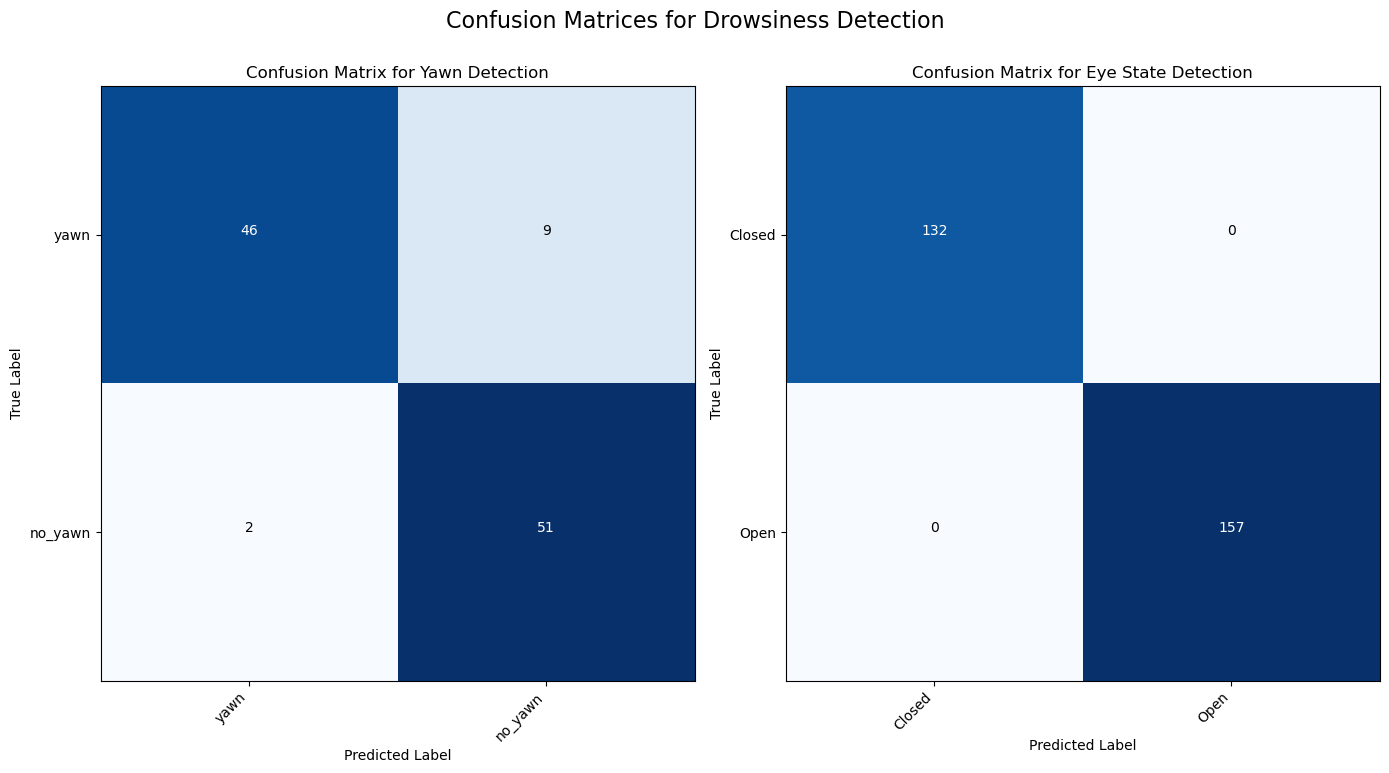

In [ ]:
# Predictions for Yawns
mask_1 = (y_true == 0) | (y_true == 1)
y_true_copy = y_true[mask_1]
y_pred_copy = y_pred[mask_1]

mask_2 = (y_true == 2) | (y_true == 3)
y_true_copy_2 = y_true[mask_2]
y_pred_copy_2 = y_pred[mask_2]


cm_1 = confusion_matrix(y_true_copy, y_pred_copy)
cm_2 = confusion_matrix(y_true_copy_2, y_pred_copy_2)

# 0=yawn, 1=no_yawn, 2=Closed, 3=Open
class_names_1 = ["yawn", "no_yawn"]
class_names_2 = ["Closed", "Open"]
label_ids = list(range(len(class_names_1)))

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# --- CM 1 ---
ax = axes[0]
ax.imshow(cm_1, interpolation="nearest", cmap=plt.cm.Blues)
ax.set_title("Confusion Matrix for Yawn Detection")
ax.set_xticks(np.arange(len(class_names_1)))
ax.set_yticks(np.arange(len(class_names_1)))
ax.set_xticklabels(class_names_1, rotation=45, ha="right")
ax.set_yticklabels(class_names_1)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

threshold = cm_1.max() / 2.0
for i in range(cm_1.shape[0]):
    for j in range(cm_1.shape[1]):
        ax.text(j, i, cm_1[i, j],
                ha="center",
                color="white" if cm_1[i, j] > threshold else "black")

# --- CM 2 ---
ax = axes[1]
ax.imshow(cm_2, interpolation="nearest", cmap=plt.cm.Blues)
ax.set_title("Confusion Matrix for Eye State Detection")
ax.set_xticks(np.arange(len(class_names_2)))
ax.set_yticks(np.arange(len(class_names_2)))
ax.set_xticklabels(class_names_2, rotation=45, ha="right")
ax.set_yticklabels(class_names_2)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')


threshold = cm_2.max() / 2.0
for i in range(cm_2.shape[0]):
    for j in range(cm_2.shape[1]):
        ax.text(j, i, cm_2[i, j],
                ha="center",
                color="white" if cm_2[i, j] > threshold else "black")

plt.tight_layout()
plt.suptitle("Confusion Matrices for Drowsiness Detection", fontsize=16)
plt.show()


## Inference Demo (Image First, Then Webcam)

In [ ]:
from tensorflow.keras.models import load_model
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Class index contract from training pipeline.
IMG_SIZE = 160
CLASS_NAMES = {
    0: "yawn",
    1: "no_yawn",
    2: "eyes_closed",
    3: "eyes_open",
}

EYE_CLASS_IDS = [2, 3]
MOUTH_CLASS_IDS = [0, 1]
CONFIDENCE_THRESHOLD = 0.55

# Reuse the best checkpoint if available, otherwise fallback to in-memory model objects.
checkpoint_path = "best_mobilenetv2_drowsiness.keras"
if os.path.exists(checkpoint_path):
    model_for_inference = load_model(checkpoint_path)
elif "best_model" in globals():
    model_for_inference = best_model
else:
    model_for_inference = model

face_cascade_infer = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
eye_cascade_infer = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

def preprocess_roi_for_model(roi_bgr, img_size=IMG_SIZE):
    if roi_bgr is None or roi_bgr.size == 0:
        return None
    resized = cv2.resize(roi_bgr, (img_size, img_size))
    rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB).astype(np.float32)
    x = preprocess_input(rgb)
    return np.expand_dims(x, axis=0)

def predict_subset(roi_bgr, allowed_ids):
    x = preprocess_roi_for_model(roi_bgr)
    if x is None:
        return "not_detected", 0.0
    probs = model_for_inference.predict(x, verbose=0)[0]
    subset = np.array([probs[i] for i in allowed_ids], dtype=np.float32)
    subset = subset / (subset.sum() + 1e-8)
    best_local_idx = int(np.argmax(subset))
    class_id = allowed_ids[best_local_idx]
    confidence = float(subset[best_local_idx])
    if confidence < CONFIDENCE_THRESHOLD:
        return "uncertain", confidence
    return CLASS_NAMES[class_id], confidence

def draw_box_with_label(image_bgr, box, label, confidence, color):
    x, y, w, h = box
    cv2.rectangle(image_bgr, (x, y), (x + w, y + h), color, 2)
    text = f"{label} ({confidence:.2f})"
    cv2.putText(image_bgr, text, (x, max(20, y - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2, cv2.LINE_AA)

def mouth_box_from_face(face_box):
    x, y, w, h = face_box
    mx = x + int(0.18 * w)
    my = y + int(0.58 * h)
    mw = int(0.64 * w)
    mh = int(0.34 * h)
    return (mx, my, mw, mh)

def detect_and_annotate_states(image_bgr):
    output = image_bgr.copy()
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    faces = face_cascade_infer.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=5, minSize=(80, 80))

    if len(faces) == 0:
        # Fallback: run mouth-state prediction on the full frame.
        label, conf = predict_subset(image_bgr, MOUTH_CLASS_IDS)
        h, w = image_bgr.shape[:2]
        draw_box_with_label(output, (10, 10, w - 20, h - 20), f"fallback_mouth:{label}", conf, (0, 165, 255))
        return output

    for (x, y, w, h) in faces:
        face_box = (x, y, w, h)
        cv2.rectangle(output, (x, y), (x + w, y + h), (255, 255, 0), 2)
        cv2.putText(output, "face", (x, max(20, y - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 0), 2, cv2.LINE_AA)

        face_gray = gray[y:y+h, x:x+w]
        face_bgr = image_bgr[y:y+h, x:x+w]

        eyes = eye_cascade_infer.detectMultiScale(face_gray, scaleFactor=1.15, minNeighbors=6, minSize=(20, 20))
        eyes = sorted(eyes, key=lambda e: e[0])[:2]

        for (ex, ey, ew, eh) in eyes:
            eye_roi = face_bgr[ey:ey+eh, ex:ex+ew]
            eye_label, eye_conf = predict_subset(eye_roi, EYE_CLASS_IDS)
            global_eye_box = (x + ex, y + ey, ew, eh)
            draw_box_with_label(output, global_eye_box, f"eye:{eye_label}", eye_conf, (0, 255, 0))

        mbox = mouth_box_from_face(face_box)
        mx, my, mw, mh = mbox
        mouth_roi = image_bgr[my:my+mh, mx:mx+mw]
        mouth_label, mouth_conf = predict_subset(mouth_roi, MOUTH_CLASS_IDS)
        draw_box_with_label(output, mbox, f"mouth:{mouth_label}", mouth_conf, (0, 0, 255))

    return output

### Testing model on images

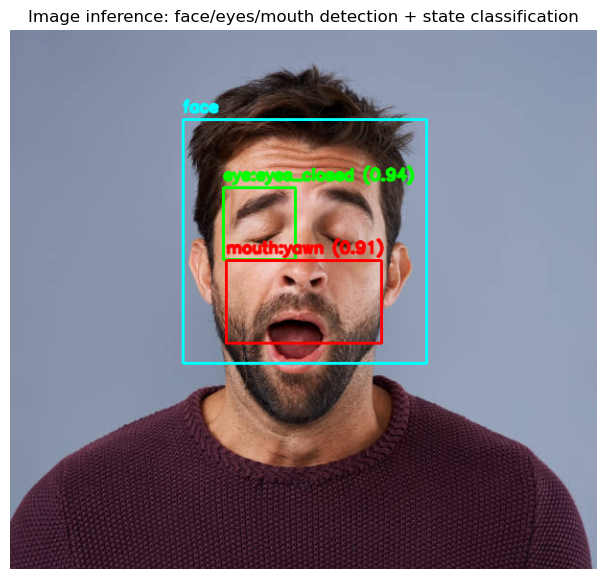

In [ ]:
# IMAGE DEMO: set any local image path here and run this cell.
image_path = "test_im_2.jpg"

image_bgr = cv2.imread(image_path)
if image_bgr is None:
    raise FileNotFoundError(f"Could not read image: {image_path}")

annotated = detect_and_annotate_states(image_bgr)

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Image inference: face/eyes/mouth detection + state classification")
plt.show()

### Trying WEBCAM DEMO

In [ ]:
# WEBCAM DEMO: run this cell after image demo works.
# Press 'q' in the webcam window to quit.

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise RuntimeError("Could not open webcam. Make sure camera permissions are enabled.")

print("Webcam started. Press 'q' to quit.")
while True:
    ok, frame = cap.read()
    if not ok:
        break

    annotated = detect_and_annotate_states(frame)
    cv2.imshow("Drowsiness Demo - face/eyes/mouth", annotated)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()
print("Webcam stopped.")

Webcam started. Press 'q' to quit.
Webcam stopped.


In [ ]:
import cv2
import numpy as np

# Input video path (update as needed)
video_path = "train/n_1.mp4"  # Your video file

# Output cropped video path
output_path = "cropped_faces.mp4"

# Load cascades (reuse from your code)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {video_path}")

# Get video properties
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Output video writer (cropped size: 160x160)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (160, 160))

print("Processing video and cropping faces...")
frame_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=5, minSize=(80, 80))
    
    if len(faces) > 0:
        # Crop the first detected face (or loop for multiple)
        x, y, w, h = faces[0]
        face_crop = frame[y:y+h, x:x+w]
        # Resize to 160x160
        resized_crop = cv2.resize(face_crop, (160, 160))
        out.write(resized_crop)
        frame_count += 1
    
    # Optional: show progress every 100 frames
    if frame_count % 100 == 0:
        print(f"Processed {frame_count} frames")

cap.release()
out.release()
print(f"Cropped video saved as {output_path} with {frame_count} frames.")

Processing video and cropping faces...
Processed 100 frames
Cropped video saved as cropped_faces.mp4 with 155 frames.


In [ ]:
# VIDEO DEMO: test model on a video file.
# Set the video path here (e.g., "train/your_video.mp4" or full path).
video_path = "train/d_1.mp4"  # Replace with your video file path

cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {video_path}")

print("Video started. Press 'q' to quit.")
while True:
    ok, frame = cap.read()
    if not ok:
        break

    annotated = detect_and_annotate_states(frame)
    cv2.imshow("Drowsiness Demo - Video", annotated)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()
print("Video stopped.")

NameError: name 'cv2' is not defined